# 07. The BSTS as an operational forecaster

Notebooks 03 to 06 scored the BSTS. This one puts it to work the way a
control-room would: pick a real high-demand winter evening, forecast it,
re-forecast it as the event approaches, and read off the operational risk
numbers that matter, all from one generative model. Every panel here is a
functional of the joint predictive, a peak, a ramp, a threshold exceedance, a
stress duration, and only a model that samples coherent whole-day trajectories
can produce them.

The model is fitted once, by warm-started NUTS (BSTS-NUTS) on the contiguous training series,
so it can forecast from any origin (notebook 06). Here I issue it repeatedly: a
sequence of forecasts for the same target evening, each conditioning on the
demand observed up to its issue time and on a weather forecast whose error
shrinks as the event nears. The story is how the forecast, and its risk
numbers, sharpen across those updates.

In [1]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")  # quiet the tqdm widget notice

import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.features.weather import degree_days
from nemforecastdemand.models import bsts, innovations
from nemforecastdemand.models.base import build_design, perturbation_overrides, variance_design
from nemforecastdemand.models.predict import fit_perturbation_models
from nemforecastdemand.plotting import (
    MODEL_COLOURS,
    density_ribbon,
    model_shades,
    palette,
    save_figure,
    sequential_cmap,
    setup_style,
)
from nemforecastdemand.splits import horizon_index
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()

panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
fit_index = splits["train"].index[max(cfg.features.demand_lags) :]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
# NUTS is the operational forecaster here; draws are the flattened, thinned
# posterior of the AR sites (the full-rank ADVI fit it is certified against
# lives in notebooks 03 and 04).
_sites = ("phi1", "phi2", "beta", "gamma0", "gamma")
nuts = load_artifact(cfg.paths.artifacts / "bsts_innovations_nuts_warm_fullrank_w300")[0]
_flat = {name: nuts[f"post_{name}"].reshape(-1, *nuts[f"post_{name}"].shape[2:]) for name in _sites}
_thin = max(_flat["phi1"].shape[0] // 1000, 1)
draws = {name: value[::_thin] for name, value in _flat.items()}
perturbations = fit_perturbation_models(panel, splits["train"].index)

LOCAL = "Australia/Brisbane"  # AEST, no daylight saving, the market clock
BSTS_C = MODEL_COLOURS["BSTS-NUTS"]
# The console density field uses the demand blue, not the BSTS amber, so it never
# competes with the green/amber/red alert axis it shares the figure with.
CONSOLE_CMAP = sequential_cmap(palette("demand"))
ALERT = {"green": "#43a047", "amber": "#f9a825", "red": "#c62828"}  # operator status, not models

## The target and the issue schedule

The target is the evening peak of 1 July 2025, a winter cold snap that reached
13.1 GW, 95.6 percent of the highest demand seen anywhere in the training
history. The operator wants to know, ahead of time, how high the evening will
climb and how likely it is to threaten the record, so the spike threshold is
set as a fraction of that past observed maximum.

I issue forecasts at 24, 18, 12, 6 and 3 hours before the nominal 18:00 peak, a
realistic intraday cadence. Each later issue has seen more of the day unfold and
is paired with a sharper weather forecast: the day-ahead weather error
(calibrated in notebook 05) is scaled down in proportion to lead time, so the
3-hour forecast runs on near-perfect weather and the 24-hour forecast on the
full day-ahead error.

In [2]:
TARGET_DATE = pd.Timestamp("2025-07-01").date()
PEAK_LOCAL = pd.Timestamp(f"{TARGET_DATE} 18:00", tz=LOCAL)
EVENING = (15, 21)  # local hours bounding the evening peak window
LEADS = [24, 18, 12, 6, 3]  # hours before the nominal peak
HERO_LEAD = 3  # the "current" operational forecast for the console view
THRESH_FRACTIONS = [0.85, 0.90, 0.95]

# Past observed maximum, strictly before the target day starts.
hist_max = float(panel["demand_mw"].loc[: (PEAK_LOCAL.normalize().tz_convert("UTC"))].iloc[:-1].max())
thresholds = {f: f * hist_max for f in THRESH_FRACTIONS}
window = panel.loc[
    PEAK_LOCAL.tz_convert("UTC") - pd.Timedelta(days=12) : PEAK_LOCAL.tz_convert("UTC")
    + pd.Timedelta(days=2)
].copy()
print(f"target evening: {TARGET_DATE}, past observed maximum {hist_max:.0f} MW")
print("spike thresholds (MW):", {f: round(v) for f, v in thresholds.items()})


def vintage_paths(origin, multiplier, n_weather=10, seed0=0):
    """Predictive paths (S, 48) in MW from one issue time, pooling demand-model
    uncertainty over a small ensemble of weather forecasts whose error scales
    with lead. History uses realised weather; the horizon uses the forecast."""
    hist = window.index[
        (window.index >= inputs.index[0]) & (window.index <= origin + pd.Timedelta(hours=24))
    ]
    design = build_design(window, cfg, "actual").loc[hist]
    vdesign = variance_design(window, cfg, "actual").loc[hist]
    x_hist, _ = bsts.transform_design(inputs, design, vdesign)
    y_hist = ((window["demand_mw"].loc[hist].to_numpy() - inputs.y_loc) / inputs.y_scale).astype(
        np.float32
    )
    e0 = innovations.origin_residuals(draws, y_hist, x_hist, hist.get_indexer([origin]))
    target = horizon_index(origin, cfg.horizon)
    segments = []
    for k, group in enumerate(np.array_split(np.arange(e0.shape[0]), n_weather)):
        if multiplier > 0:
            overrides = perturbation_overrides(
                window, target, perturbations, multiplier, cfg.seed + seed0 + k
            )
            hblock = build_design(window, cfg, "actual", overrides=overrides).loc[target]
            vblock = vdesign.loc[target].copy()
            deg = degree_days(overrides["temp_c"], cfg.weather.heating_base, cfg.weather.cooling_base)
            vblock[["cooling_deg", "heating_deg"]] = deg.to_numpy()
        else:
            hblock, vblock = design.loc[target], vdesign.loc[target]
        xf, zf = bsts.transform_design(inputs, hblock, vblock)
        block_draws = {name: value[group] for name, value in draws.items()}
        sim = innovations.simulate_horizon_paths(
            block_draws, e0[group], xf[None], zf[None], cfg.bsts, seed=cfg.seed + seed0 * 97 + k
        )
        segments.append(np.asarray(sim[:, 0, :]))
    return np.concatenate(segments) * inputs.y_scale + inputs.y_loc, target


vintages = {}
for lead in LEADS:
    origin = (PEAK_LOCAL - pd.Timedelta(hours=lead)).tz_convert("UTC")
    paths, target = vintage_paths(origin, multiplier=lead / 24.0, seed0=lead)
    vintages[lead] = {"paths": paths, "target": target, "origin": origin}
    print(f"  issued {lead:2d}h ahead at {origin.tz_convert(LOCAL):%d %b %H:%M}: {paths.shape[0]} paths")


def evening_slice(target):
    """Boolean mask of the target-evening half hours within a horizon index."""
    local = target.tz_convert(LOCAL)
    same_day = np.array([t.date() == TARGET_DATE for t in local])
    return same_day & (local.hour >= EVENING[0]) & (local.hour <= EVENING[1])


def peak_draws(record):
    """Per-path maximum demand over the target evening, (S,)."""
    return record["paths"][:, evening_slice(record["target"])].max(axis=1)

target evening: 2025-07-01, past observed maximum 13716 MW
spike thresholds (MW): {0.85: 11658, 0.9: 12344, 0.95: 13030}


  issued 24h ahead at 30 Jun 18:00: 1000 paths


  issued 18h ahead at 01 Jul 00:00: 1000 paths


  issued 12h ahead at 01 Jul 06:00: 1000 paths


  issued  6h ahead at 01 Jul 12:00: 1000 paths


  issued  3h ahead at 01 Jul 15:00: 1000 paths


*Takeaway: the target is a near-record winter evening, with five vintages issued from 24 down to 3 hours ahead on progressively sharper weather.*

## The console: tonight's forecast

This is the current operational view, the forecast issued three hours before the
peak. The fan is the predictive density field, deepest where the forecast is
densest, with the 50 and 90 percent intervals as dotted lines and the median; the
dashed line is the spike threshold at 95 percent of the past maximum, and the red
wash is the exceedance region. The panel on the right is
the readout an operator acts on: the forecast peak with its 90 percent
interval, the probability of a spike, the expected stress hours, the steepest
expected ramp, and an alert status driven by the spike probability.

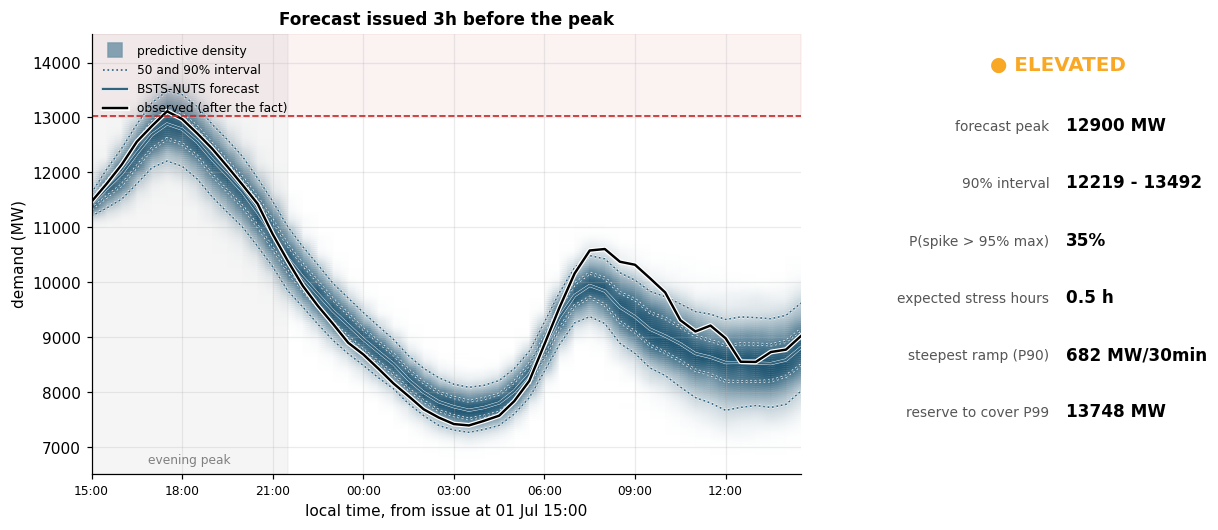

In [3]:
def alert_for(prob):
    return "red" if prob > 0.5 else "amber" if prob > 0.15 else "green"


# Descriptive status words for the console, keyed by the traffic-light colour.
STATUS_LABEL = {"green": "NORMAL", "amber": "ELEVATED", "red": "SPIKE LIKELY"}


hero = vintages[HERO_LEAD]
htarget = hero["target"]
hlocal = htarget.tz_convert(LOCAL)
hx = np.arange(cfg.horizon)
evening = evening_slice(htarget)
spike = thresholds[0.95]
pk = peak_draws(hero)
p_spike = float((pk > spike).mean())
stress_hours = (hero["paths"] > spike).sum(axis=1) * 0.5
ramp = np.diff(hero["paths"], axis=1).max(axis=1)
obs_hero = panel["demand_mw"].loc[htarget].to_numpy()

fig = plt.figure(figsize=(13, 5.2))
grid = fig.add_gridspec(1, 3, width_ratios=[2.5, 0.05, 1.0], wspace=0.15)
ax = fig.add_subplot(grid[0, 0])
density_ribbon(
    ax,
    hx,
    samples=hero["paths"],
    observed=obs_hero,
    cmap=CONSOLE_CMAP,
    label="BSTS-NUTS forecast",
    observed_label="observed (after the fact)",
)
ax.axhline(spike, color=ALERT["red"], ls="--", lw=1.1)
ax.fill_between(hx, spike, ax.get_ylim()[1], color=ALERT["red"], alpha=0.06)
ax.axvspan(np.where(evening)[0][0], np.where(evening)[0][-1], color="grey", alpha=0.08)
ax.text(np.where(evening)[0].mean(), ax.get_ylim()[0] + 200, "evening peak", ha="center", fontsize=8, color="grey")
tick = np.arange(0, cfg.horizon, 6)
ax.set_xticks(tick)
ax.set_xticklabels([f"{hlocal[t]:%H:%M}" for t in tick], fontsize=8)
ax.set_xlabel(f"local time, from issue at {hero['origin'].tz_convert(LOCAL):%d %b %H:%M}")
ax.set_ylabel("demand (MW)")
ax.set_title(f"Forecast issued {HERO_LEAD}h before the peak")
ax.legend(loc="upper left", fontsize=8)

panel_ax = fig.add_subplot(grid[0, 2])
panel_ax.axis("off")
status = alert_for(p_spike)
# A descriptive status badge centred over a centred key-value readout, so the
# panel reads as a balanced card rather than text justified hard to the edges.
panel_ax.text(
    0.5,
    0.93,
    f"● {STATUS_LABEL[status]}",
    va="center",
    ha="center",
    fontsize=13,
    weight="bold",
    color=ALERT[status],
    transform=panel_ax.transAxes,
)
lines = [
    ("forecast peak", f"{np.median(pk):.0f} MW"),
    ("90% interval", f"{np.quantile(pk, 0.05):.0f} - {np.quantile(pk, 0.95):.0f}"),
    (f"P(spike > {THRESH_FRACTIONS[-1]:.0%} max)", f"{p_spike:.0%}"),
    ("expected stress hours", f"{stress_hours.mean():.1f} h"),
    ("steepest ramp (P90)", f"{np.quantile(ramp, 0.9):.0f} MW/30min"),
    ("reserve to cover P99", f"{np.quantile(pk, 0.99):.0f} MW"),
]
for i, (k, v) in enumerate(lines):
    y = 0.78 - i * 0.13
    panel_ax.text(0.47, y, k, fontsize=9, color="#555", ha="right", transform=panel_ax.transAxes)
    panel_ax.text(0.53, y, v, fontsize=11, weight="bold", ha="left", transform=panel_ax.transAxes)
save_figure(fig, "ops_console", cfg.paths.figures)
plt.show()

*Takeaway: one fitted model fills the whole console, the peak with its interval, the spike probability, stress hours, ramp and a reserve quantile, all from a single joint predictive.*

## How the forecast sharpens as the event nears

The same evening, forecast at each issue time. The left panel overlays the
median and 80 percent band of every vintage, coloured from the earliest to the
latest, against what actually happened. The right panel tells the same story as
two numbers: the forecast peak, with its 10 to 90 percent range, homing in on
the realised peak as the lead shrinks.

The honest lesson is in the early vintages. A day out, the model forecasts an
ordinary winter evening near 11 GW, because the seasonal and weather terms have
no reason yet to expect a record. Only as the cold snap shows up in the demand
observed through the afternoon does the AR([1,2]) error carry the elevated level
into the evening and the forecast climb to meet the peak. The band here is
driven mainly by intrinsic demand volatility rather than weather-forecast
error, so it tightens most in the final hours as the AR anchor takes hold. This
is exactly why operators re-forecast intraday, and the probabilistic model
makes the value of each update explicit.

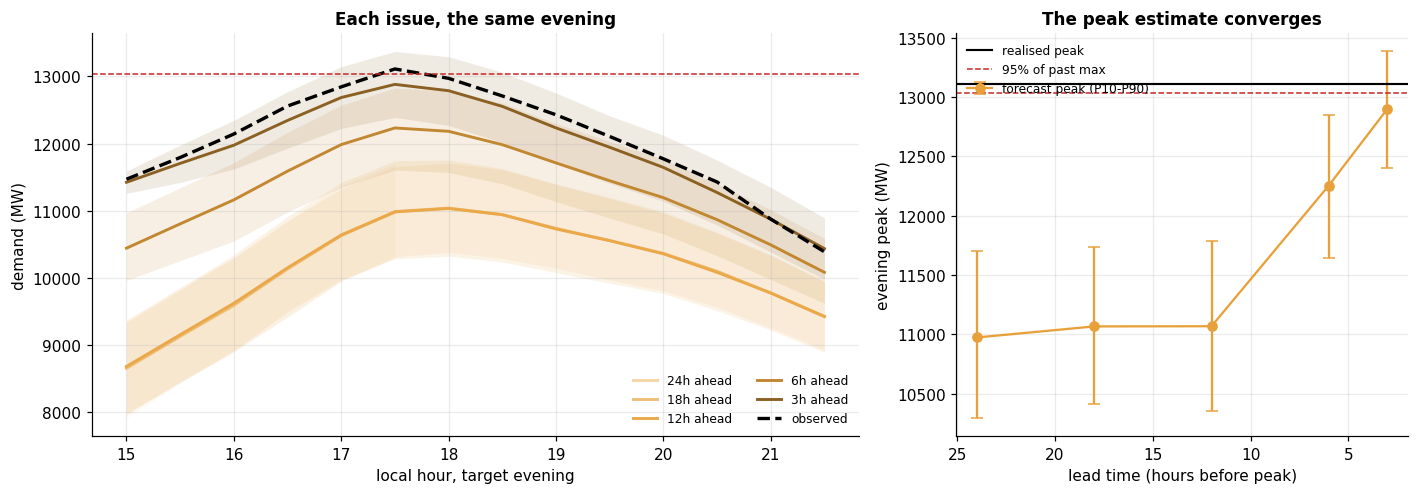

In [4]:
fig, (axf, axp) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.7, 1.0]})
shades = model_shades("BSTS-NUTS", len(LEADS))
ev_local = None
for colour, lead in zip(shades, LEADS, strict=True):
    rec = vintages[lead]
    mask = evening_slice(rec["target"])
    et = rec["target"][mask].tz_convert(LOCAL)
    ev_local = et
    ev_paths = rec["paths"][:, mask]
    hours = et.hour + et.minute / 60
    axf.fill_between(hours, np.quantile(ev_paths, 0.1, 0), np.quantile(ev_paths, 0.9, 0), color=colour, alpha=0.13, lw=0)
    axf.plot(hours, np.median(ev_paths, 0), color=colour, lw=1.9, label=f"{lead}h ahead")
obs_ev = panel["demand_mw"].loc[vintages[HERO_LEAD]["target"]][evening_slice(vintages[HERO_LEAD]["target"])]
axf.plot(ev_local.hour + ev_local.minute / 60, obs_ev.to_numpy(), color="black", lw=2.2, ls="--", label="observed")
axf.axhline(spike, color=ALERT["red"], ls="--", lw=1.0)
axf.set_xlabel("local hour, target evening")
axf.set_ylabel("demand (MW)")
axf.set_title("Each issue, the same evening")
axf.legend(fontsize=8, ncol=2)

med = [np.median(peak_draws(vintages[lead])) for lead in LEADS]
lo = [np.quantile(peak_draws(vintages[lead]), 0.1) for lead in LEADS]
hi = [np.quantile(peak_draws(vintages[lead]), 0.9) for lead in LEADS]
axp.errorbar(LEADS, med, yerr=[np.array(med) - lo, np.array(hi) - med], fmt="o-", color=BSTS_C, capsize=4, label="forecast peak (P10-P90)")
axp.axhline(obs_ev.max(), color="black", lw=1.4, ls="-", label="realised peak")
axp.axhline(spike, color=ALERT["red"], ls="--", lw=1.0, label=f"{THRESH_FRACTIONS[-1]:.0%} of past max")
axp.set_xlabel("lead time (hours before peak)")
axp.set_ylabel("evening peak (MW)")
axp.set_title("The peak estimate converges")
axp.invert_xaxis()
axp.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "ops_forecast_evolution", cfg.paths.figures)
plt.show()

*Takeaway: a day out the model expects an ordinary evening; as the afternoon's elevated demand arrives the forecast climbs and its peak estimate converges on the realised peak.*

## Spike probability, and how it resolves

This is the metric a control-room cares about most: the probability that the
evening breaches a high-load threshold, tracked as the forecast updates. I show
three thresholds, each a fraction of the past observed maximum. As the lead
shrinks the probabilities resolve towards zero or one, and the background
shading is the alert status the operator would post (green, amber or red) off
the strictest threshold. A day out the model is relaxed, giving the evening
barely a one-in-ten chance of clearing even the lowest threshold. By early
afternoon the two lower thresholds have resolved to near-certain, while the
strict record threshold, a genuinely marginal call, lifts to about a third only
in the final vintages, and the evening went on to edge just past it.

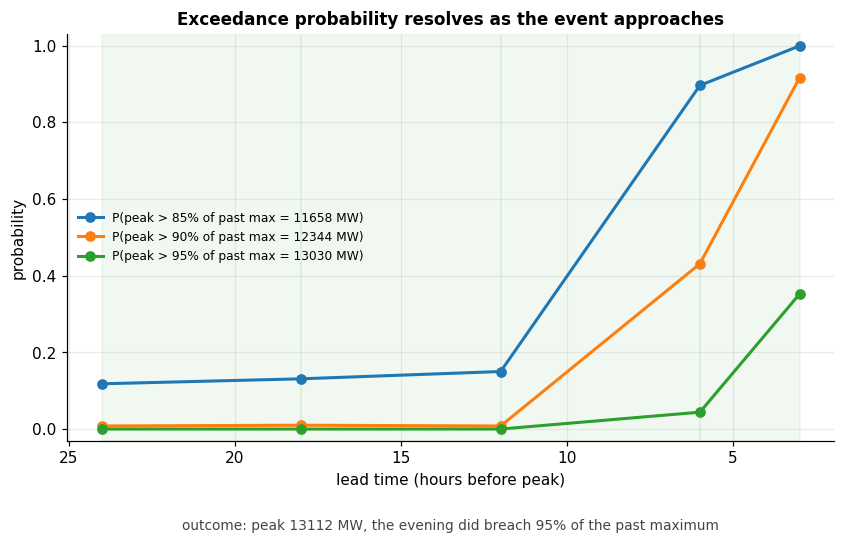

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
realised_peak = obs_ev.max()
for frac in THRESH_FRACTIONS:
    probs = [float((peak_draws(vintages[lead]) > thresholds[frac]).mean()) for lead in LEADS]
    ax.plot(LEADS, probs, "o-", lw=2, label=f"P(peak > {frac:.0%} of past max = {thresholds[frac]:.0f} MW)")
strict = [float((peak_draws(vintages[lead]) > thresholds[0.95]).mean()) for lead in LEADS]
for x0, x1, lead_prob in zip(LEADS[:-1], LEADS[1:], strict[:-1], strict=True):
    band = alert_for(lead_prob)
    ax.axvspan(min(x0, x1), max(x0, x1), color=ALERT[band], alpha=0.07)
ax.set_xlabel("lead time (hours before peak)")
ax.set_ylabel("probability")
ax.set_ylim(-0.03, 1.03)
ax.invert_xaxis()
ax.set_title("Exceedance probability resolves as the event approaches")
outcome = "the evening did breach 95% of the past maximum" if realised_peak > thresholds[0.95] else "the evening stayed below 95%"
ax.text(0.5, -0.22, f"outcome: peak {realised_peak:.0f} MW, {outcome}", transform=ax.transAxes, ha="center", fontsize=9, color="#444")
ax.legend(fontsize=8, loc="center left")
save_figure(fig, "ops_spike_probability", cfg.paths.figures)
plt.show()

*Takeaway: the lower-threshold probabilities resolve to near-certain early enough to act on, while the strict record threshold stays a calibrated coin-toss to the end, matching how narrowly the evening cleared it.*

## The operator's risk grid

Three functionals of the same coherent paths, all from the three-hour forecast,
and not one of them is something a set of independent per-step quantiles could
produce.

- **Steepest ramp.** The largest half-hour rise in the day, which sizes
  fast-start and regulation reserve, with the chance it clears a trigger.
- **Stress duration.** How many half hours sit above the threshold, the length
  of the exposure rather than just its peak.
- **Coherent scenarios.** A handful of whole-day trajectories to feed a
  downstream study (reserve, storage, power flow), each physically plausible
  rather than a jagged draw from per-step marginals.

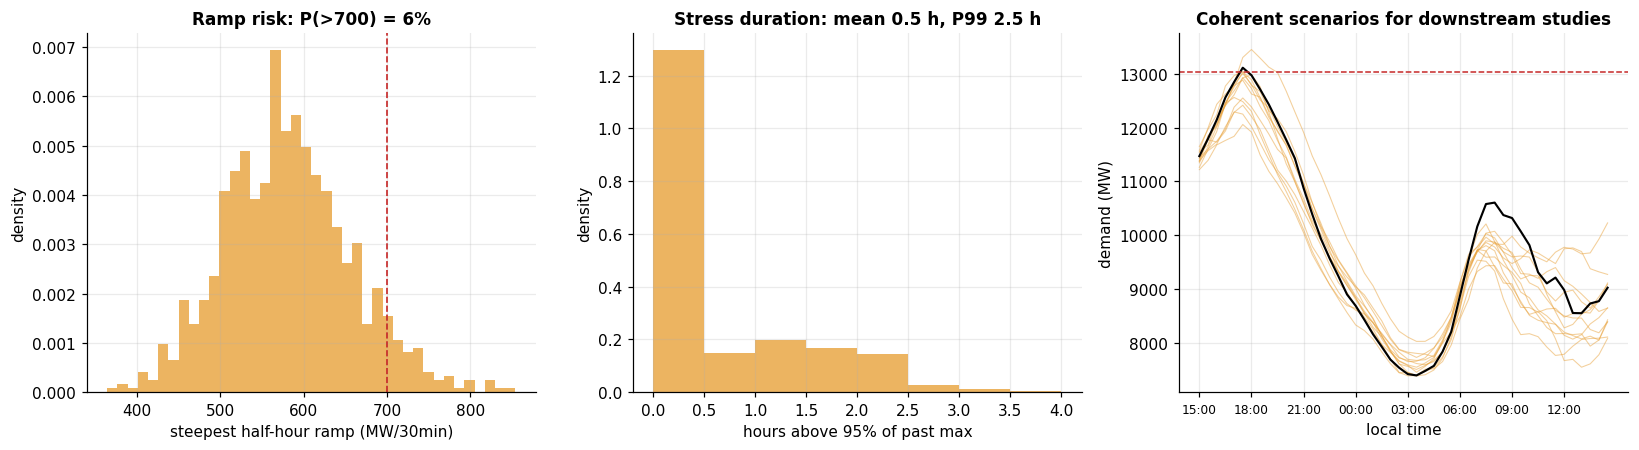

In [6]:
ramp_trigger = 700.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(ramp, bins=40, color=BSTS_C, alpha=0.8, density=True)
axes[0].axvline(ramp_trigger, color=ALERT["red"], ls="--", lw=1.1)
axes[0].set_xlabel("steepest half-hour ramp (MW/30min)")
axes[0].set_ylabel("density")
axes[0].set_title(f"Ramp risk: P(>{ramp_trigger:.0f}) = {(ramp > ramp_trigger).mean():.0%}")

bins = np.arange(0, stress_hours.max() + 1.0, 0.5)
axes[1].hist(stress_hours, bins=bins, color=BSTS_C, alpha=0.8, density=True)
axes[1].set_xlabel(f"hours above {THRESH_FRACTIONS[-1]:.0%} of past max")
axes[1].set_ylabel("density")
axes[1].set_title(f"Stress duration: mean {stress_hours.mean():.1f} h, P99 {np.quantile(stress_hours, 0.99):.1f} h")

for s in range(12):
    axes[2].plot(hx, hero["paths"][s], color=BSTS_C, lw=0.7, alpha=0.5)
axes[2].plot(hx, obs_hero, color="black", lw=1.4)
axes[2].axhline(spike, color=ALERT["red"], ls="--", lw=1.0)
axes[2].set_xticks(tick)
axes[2].set_xticklabels([f"{hlocal[t]:%H:%M}" for t in tick], fontsize=8)
axes[2].set_xlabel("local time")
axes[2].set_ylabel("demand (MW)")
axes[2].set_title("Coherent scenarios for downstream studies")
fig.tight_layout()
save_figure(fig, "ops_risk_grid", cfg.paths.figures)
plt.show()

*Takeaway: ramp risk, stress duration and whole-day scenarios all come off the one joint predictive, and none of them exists for a bank of independent quantiles.*

## What the operator gets from the BSTS

One fitted model, issued repeatedly, supplies the whole console: a calibrated
density for the evening, a peak estimate that sharpens as the day reveals
itself, a spike probability that resolves in time to act on, ramp and
stress-duration risk, a reserve quantile, and coherent scenarios for downstream
studies. The numbers update coherently because they are all read off the same
joint predictive, and the model says plainly when it is uncertain and when it
is confident. A bank of independent quantile heads can give a forecaster the
central path; it cannot give the control-room the joint risk picture this
notebook is built from.